In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


### Load and Preprocess the MNIST Dataset

First, we'll load the MNIST dataset, which consists of handwritten digits. Then, we'll preprocess the images by normalizing pixel values and reshaping them. Finally, we'll one-hot encode the labels, which is required for categorical cross-entropy.

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape images to (num_samples, 28, 28, 1) for CNN input
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Convert labels to one-hot encoding
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1), y_train shape: (60000, 10)
x_test shape: (10000, 28, 28, 1), y_test shape: (10000, 10)


### Define a Simple Convolutional Neural Network (CNN) Model

We'll create a simple sequential model with a convolutional layer, a max-pooling layer, and dense layers for classification. This architecture is effective for image classification tasks like MNIST.

In [3]:
# Define the model
model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

### Compile the Model

We'll compile the model using the Adam optimizer, `categorical_crossentropy` as the loss function (since our labels are one-hot encoded), and `accuracy` as a metric to monitor performance.

In [4]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

### Train the Model

Now, let's train the model on the training data and validate it on the test data. The `model.fit()` method will return a `history` object that contains training loss and accuracy values for each epoch.

In [5]:
# Train the model
history = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))

# Evaluate the model on the test sety

loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 23ms/step - accuracy: 0.9570 - loss: 0.1467 - val_accuracy: 0.9768 - val_loss: 0.0726
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9846 - loss: 0.0515 - val_accuracy: 0.9795 - val_loss: 0.0613
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9901 - loss: 0.0327 - val_accuracy: 0.9852 - val_loss: 0.0424
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9931 - loss: 0.0218 - val_accuracy: 0.9859 - val_loss: 0.0478
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9948 - loss: 0.0153 - val_accuracy: 0.9848 - val_loss: 0.0499

Test Loss: 0.0499
Test Accuracy: 0.9848


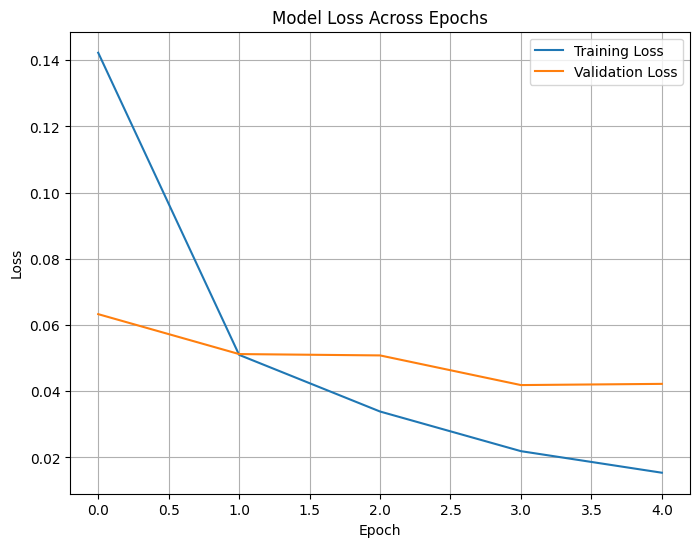

In [ ]:
# Plot training loss across epochs
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### What is a Loss Function?

AIn simple terms, a **loss function** (also called a cost function) is a way to measure how well your machine learning model is doing at making predictions. It calculates the "error" or "distance" between the predicted output of your model and the actual correct output. A smaller loss value means the model's predictions are closer to the truth, while a larger loss value indicates poor predictions.

### Role of Loss in Training Neural Networks

The loss function is crucial for training neural networks because it provides a signal that tells the model how to adjust itself. During training, the goal is to minimize this loss. The model uses the calculated loss to understand where it made mistakes and then updates its internal parameters (like weights and biases) in a way that should lead to a lower loss in the next prediction cycle. It's like a feedback mechanism that guides the learning process.

### Gradient Descent Concept

**Gradient Descent** is an optimization algorithm used to minimize the loss function. Imagine you're in a mountainous region and want to find the lowest point (which represents the minimum loss). You can't see the whole area, but you can feel the slope around you. Gradient descent works by repeatedly taking steps in the direction of the steepest descent (the negative of the gradient). Each step helps the model get closer to the lowest point of the loss function, where its predictions are most accurate. The 'gradient' tells you the direction and magnitude of the steepest slope.

### Common Loss Functions

*   **Binary Cross-Entropy (BCE)**: This loss function is typically used for **binary classification problems**, where the output is one of two classes (e.g., spam or not spam, true or false). It measures the performance of a classification model whose output is a probability value between 0 and 1.

*   **Categorical Cross-Entropy (CCE)**: This is used for **multi-class classification problems** where the labels are one-hot encoded (e.g., predicting an image is a dog, cat, or bird, and the label is `[0, 1, 0]` for cat). It measures the difference between the predicted probability distribution and the true distribution.

*   **Mean Squared Error (MSE)**: Also known as L2 Loss, MSE is commonly used for **regression problems**, where the goal is to predict a continuous value (e.g., house prices, temperature). It calculates the average of the squared differences between the predicted values and the actual values. Squaring the errors means larger errors are penalized more heavily.

### Optimizers such as SGD and Adam

**Optimizers** are algorithms or methods used to change the attributes of your neural network, such as weights and learning rate, in order to reduce the loss function. They are the 'engines' that drive the gradient descent process.

*   **Stochastic Gradient Descent (SGD)**: This is a basic form of gradient descent. Instead of calculating the gradient using the entire dataset (which can be very slow for large datasets), SGD calculates the gradient and updates the model's parameters using only a small, randomly selected subset of the data (called a 'mini-batch') at each step. This makes the training process much faster, though it can be a bit 'noisy' as the direction isn't always perfectly accurate.

*   **Adam (Adaptive Moment Estimation)**: Adam is a more advanced and popular optimizer. It combines ideas from two other extensions of SGD: AdaGrad and RMSProp. It calculates individual adaptive learning rates for different parameters. Essentially, Adam remembers past gradients and adapts the step size for each parameter, making it generally faster and more robust at converging to the minimum loss, especially in complex models and datasets.

### Plot Training Loss Across Epochs

Finally, we'll extract the training loss from the `history` object and plot it using Matplotlib to visualize how the loss decreased over the training epochs.